K-Nearest Neighbors on the wine dataset. KNN is a 'lazy learner' — no training phase, just memorizes the data and votes among the K closest points at prediction time. Distance-based, so feature scaling matters a lot.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['class'] = [wine.target_names[t] for t in y]
print("Shape:", df.shape)
print(df['class'].value_counts())
df.head()

Shape: (178, 14)
class
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# KNN is distance-based -> unscaled features with big ranges dominate the distance
print("Feature ranges before scaling:")
print(pd.DataFrame(X, columns=feature_names).describe().loc[['min', 'max']].T)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature ranges before scaling:
                                 min      max
alcohol                        11.03    14.83
malic_acid                      0.74     5.80
ash                             1.36     3.23
alcalinity_of_ash              10.60    30.00
magnesium                      70.00   162.00
total_phenols                   0.98     3.88
flavanoids                      0.34     5.08
nonflavanoid_phenols            0.13     0.66
proanthocyanins                 0.41     3.58
color_intensity                 1.28    13.00
hue                             0.48     1.71
od280/od315_of_diluted_wines    1.27     4.00
proline                       278.00  1680.00


In [3]:
# Compare scaled vs unscaled to prove the point
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

print(f"Accuracy WITHOUT scaling: {acc_unscaled*100:.2f}%")
print(f"Accuracy WITH scaling:    {acc_scaled*100:.2f}%")

Accuracy WITHOUT scaling: 72.22%
Accuracy WITH scaling:    94.44%


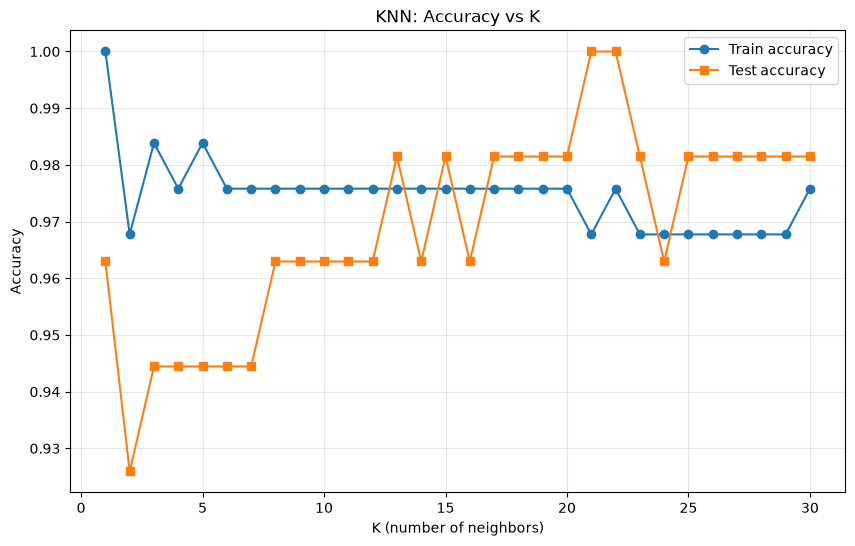

Best K by test accuracy: 21


In [4]:
# Elbow method: sweep K to find the sweet spot between underfitting and overfitting
k_range = range(1, 31)
train_acc, test_acc = [], []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_acc.append(knn.score(X_train_scaled, y_train))
    test_acc.append(knn.score(X_test_scaled, y_test))

plt.figure(figsize=(10, 6))
plt.plot(k_range, train_acc, 'o-', label='Train accuracy')
plt.plot(k_range, test_acc, 's-', label='Test accuracy')
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

best_k = k_range[int(np.argmax(test_acc))]
print(f"Best K by test accuracy: {best_k}")

In [5]:
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)
y_pred = final_knn.predict(X_test_scaled)

print(f"Final test accuracy (K={best_k}): {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=wine.target_names))

Final test accuracy (K=21): 100.00%

Confusion Matrix:
[[18  0  0]
 [ 0 21  0]
 [ 0  0 15]]

Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



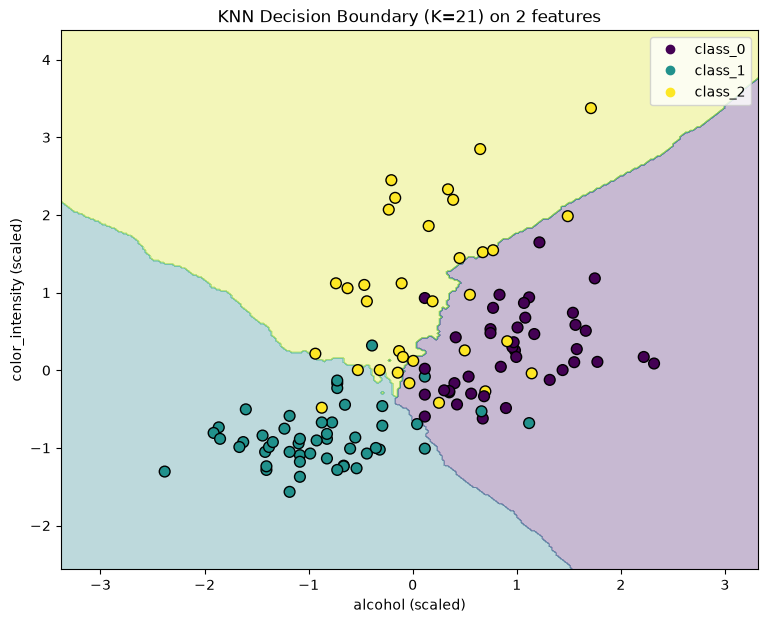

In [6]:
# Decision boundary using just 2 features (for visualization)
f1, f2 = 'alcohol', 'color_intensity'
X2 = df[[f1, f2]].values
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.3, random_state=42, stratify=y)

scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

knn2 = KNeighborsClassifier(n_neighbors=best_k)
knn2.fit(X2_train_s, y2_train)

xx, yy = np.meshgrid(
    np.linspace(X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1, 300),
    np.linspace(X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1, 300),
)
Z = knn2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
scatter = plt.scatter(X2_train_s[:, 0], X2_train_s[:, 1], c=y2_train, cmap='viridis', edgecolor='k', s=60)
plt.xlabel(f1 + ' (scaled)')
plt.ylabel(f2 + ' (scaled)')
plt.title(f'KNN Decision Boundary (K={best_k}) on 2 features')
plt.legend(handles=scatter.legend_elements()[0], labels=list(wine.target_names))
plt.show()